In [1]:
#Linear Regression
#supervised learning algorithm(giving both input and output)
#used for predicting continuous values
#finds a straight-line relationship between independent and dependent variables

# Problem Statement- To design Model using Linear Regression that predict charges(dependent varibale) based 
# on different independent variables like age,sex,bmi etc.
# To design Data science and ML Pipeline below steps need to be followed:
# OSEMN
# a. O - Obtain dataset
# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Upload data from csv file
dfi=pd.read_csv('/Users/subhashdwivedi/Desktop/Personal/Learning/IITMParvartak/Python/Projects/Linear Regression/new_insurance_data (1).csv')
dfi.shape

(1338, 13)

In [3]:
# Visually inspect the data
dfi.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


In [4]:
# Check all columns names in dataset
dfi.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [5]:
# Summary of dataset
dfi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
#EDA : Exploratory Data Analysis
#1. null values
#2. duplicates
#3. outliers
#4. label encoding

In [6]:
# Identify count of null values in dataset columns
dfi.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [8]:
# Total number of null values in dataset
dfi.isnull().sum().sum()

np.int64(52)

In [ ]:
# If want to drop null values
#Dropping null values
# df.dropna(inplace=True) inplace: permanent changes

In [9]:
# replace null values with mode in object datatypes.
# replace null values with mean in int datatypes
for col in dfi.columns:
    if dfi[col].dtype=='object':
        dfi[col]=dfi[col].fillna(dfi[col].mode()[0])
    else:
        dfi[col]=dfi[col].fillna(dfi[col].mean())

In [10]:
# verify if null values replaced
dfi.isnull().sum().sum()

np.int64(0)

In [12]:
# Check for duplicates
dfi.duplicated().sum()

np.int64(0)

In [ ]:
# if duplicate exists then drop it.
#dfi.drop_duplicates(inplace=True)

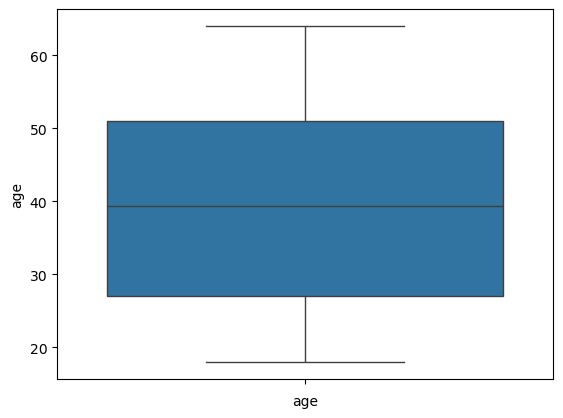

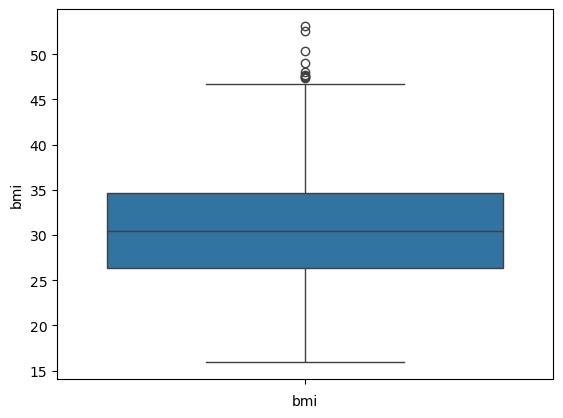

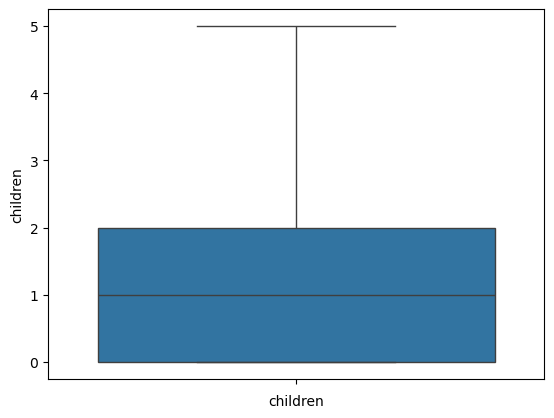

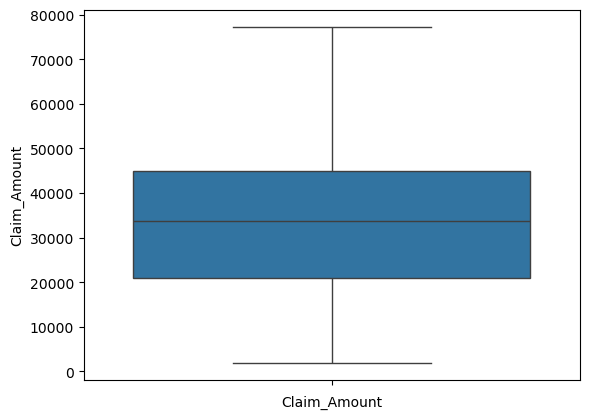

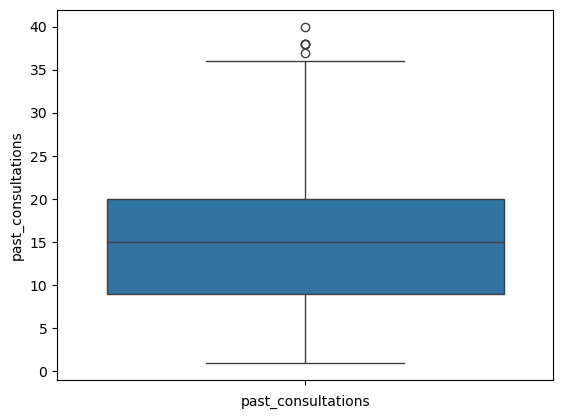

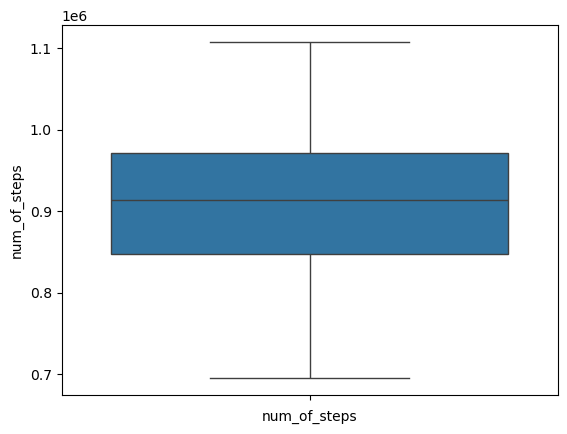

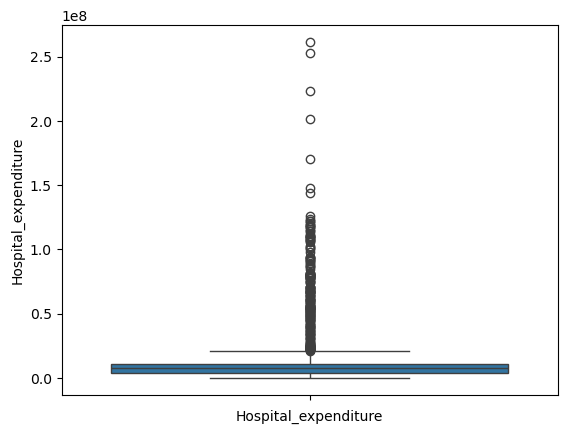

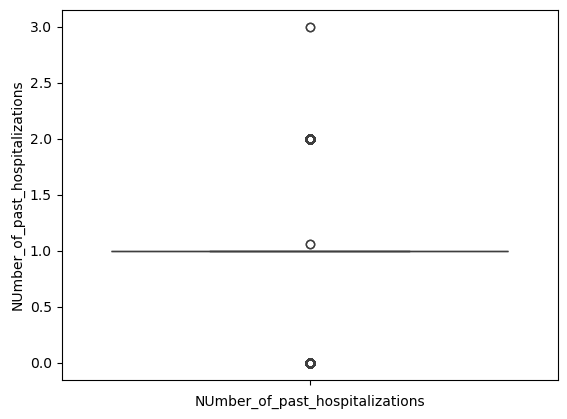

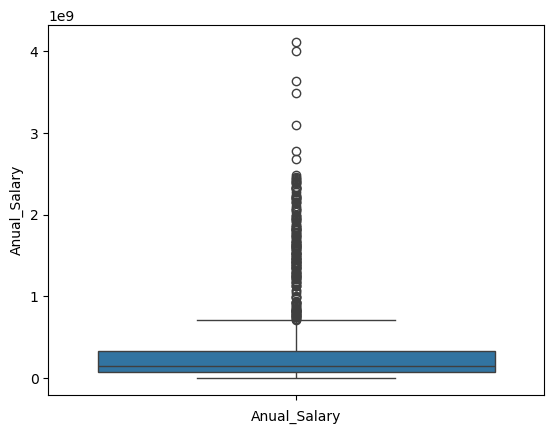

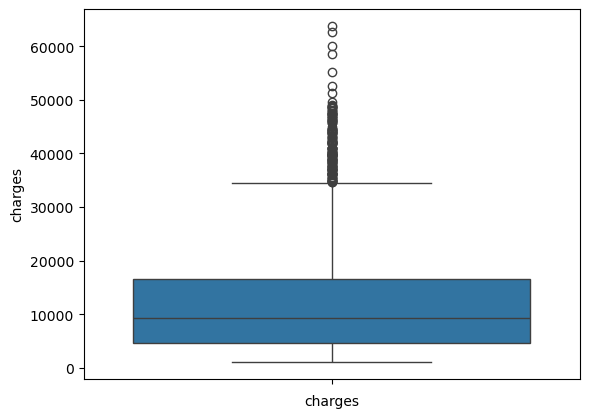

In [13]:
# Outliers visualization
for col in dfi.columns:
    if dfi[col].dtype!='object':
        sns.boxplot(dfi[col])
        plt.xlabel(col)
        plt.show()

# if no boxplot is visible, avoid touching that column
# because droping it might drop complete column which is not good.

In [17]:
# Outlier removal
outlist=['bmi','past_consultations','Hospital_expenditure','Anual_Salary']
for col in outlist:
    Q1=dfi[col].quantile(0.25)
    Q3=dfi[col].quantile(0.75)

    IQR=Q3-Q1

    LB=Q1-1.5*(IQR)
    UB=Q3+1.5*(IQR)

    dfi=dfi[(dfi[col]>=LB)&(dfi[col]<=UB)]

In [18]:
dfi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1016 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1016 non-null   float64
 1   sex                              1016 non-null   object 
 2   bmi                              1016 non-null   float64
 3   children                         1016 non-null   float64
 4   smoker                           1016 non-null   object 
 5   Claim_Amount                     1016 non-null   float64
 6   past_consultations               1016 non-null   float64
 7   num_of_steps                     1016 non-null   float64
 8   Hospital_expenditure             1016 non-null   float64
 9   NUmber_of_past_hospitalizations  1016 non-null   float64
 10  Anual_Salary                     1016 non-null   float64
 11  region                           1016 non-null   object 
 12  charges                  

In [19]:
dfi

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,24.0,male,29.830,0.0,yes,35155.45242,17.0,979075.0,1.226416e+07,1.0,3.674079e+08,northeast,18648.42170
1036,43.0,male,20.130,2.0,yes,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,southeast,18767.73770
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [21]:
# Label encoding: Convert object datatype into numerical
# arranges data into alphabetical order then gives numerical values
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()


In [25]:
#fit: understands the pattern(here, which unique category is given what number)
#transform: transform the data according the pattern understood

for col in dfi.columns:
    if(dfi[col].dtype=='object'):
        dfi[col]=LE.fit_transform(dfi[col])

In [26]:
dfi

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1034,24.0,1,29.830,0.0,1,35155.45242,17.0,979075.0,1.226416e+07,1.0,3.674079e+08,0,18648.42170
1036,43.0,1,20.130,2.0,1,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,2,18767.73770
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2,19107.77960
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0,19798.05455


In [ ]:
# Steps for Model Building
#1. splitting the data into x(features/independent) and y(target/dependent)
#2. splitting the data into TRAINING and TESTING SET
#3. Model Initialization
#4. Train the model
#5. Prediction
#6. Evaluate

In [27]:
# Split the independent variable (x)
# In Insurance dataset all columns except charges are independent.
x=dfi.iloc[:,:-1] # all columns except last(charges) i.e dependent variable(y).
# x=dfi.drop('charges')
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1034,24.0,1,29.830,0.0,1,35155.45242,17.0,979075.0,1.226416e+07,1.0,3.674079e+08,0
1036,43.0,1,20.130,2.0,1,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,2
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0


In [28]:
# split the dependent variable y
y=dfi['charges']
y

0        1121.87390
1        1131.50660
2        1135.94070
3        1136.39940
4        1137.01100
           ...     
1034    18648.42170
1036    18767.73770
1046    19107.77960
1062    19798.05455
1069    20234.85475
Name: charges, Length: 1016, dtype: float64

In [30]:
# Split training and testing data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.80,random_state=0)

In [31]:
x_train # 80% independent Questions dataset(x) for training

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
5,18.0,1,34.430,0.0,0,26488.339120,20.0,717162.0,3.696161e+06,0.0,3.696849e+08,2
356,31.0,0,25.800,2.0,0,11198.509790,19.0,836858.0,9.444052e+06,1.0,7.174640e+07,3
699,51.0,0,21.560,1.0,0,14748.823630,21.0,908963.0,3.706155e+06,1.0,1.365815e+08,2
742,53.0,0,33.250,0.0,0,33361.327180,13.0,930035.0,3.386388e+06,1.0,1.483148e+08,0
655,49.0,0,21.300,1.0,0,7319.057416,23.0,919879.0,6.934841e+06,1.0,1.409643e+08,3
...,...,...,...,...,...,...,...,...,...,...,...,...
847,57.0,0,20.100,1.0,0,53248.989970,13.0,940450.0,6.002167e+06,1.0,1.924193e+08,3
195,28.0,1,30.875,0.0,0,38337.554390,7.0,790896.0,2.009909e+06,1.0,4.823351e+07,1
636,50.0,1,26.410,0.0,0,39982.796100,17.0,922210.0,1.036373e+07,1.0,1.188551e+08,1
565,48.0,1,40.150,0.0,0,20166.247030,10.0,904825.0,9.807422e+06,1.0,1.543039e+08,2


In [32]:
y_train # 80% dependent Answer dataset(y) for training

5       1137.46970
356     4934.70500
699     9855.13140
742    10564.88450
655     9182.17000
          ...     
847    12032.32600
195     3062.50825
636     8827.20990
565     7804.16050
693     9724.53000
Name: charges, Length: 812, dtype: float64

In [33]:
x_test # 20% independent Questions dataset(x) for training

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
255,32.0,1,28.880,0.0,0,50271.770030,7.0,828698.0,9.212004e+06,1.0,6.327002e+07,1
76,20.0,0,29.600,0.0,0,6880.234658,9.0,741432.0,3.262927e+06,0.0,4.053060e+07,3
954,64.0,1,37.905,0.0,0,16468.527720,20.0,947090.0,7.812173e+06,1.0,2.699289e+08,1
665,46.0,1,25.745,3.0,0,19869.012440,11.0,900470.0,1.021216e+07,1.0,1.635565e+08,1
899,62.0,1,21.400,0.0,0,43002.746260,12.0,940170.0,9.736326e+06,1.0,1.867879e+08,3
...,...,...,...,...,...,...,...,...,...,...,...,...
497,38.0,0,19.475,2.0,0,7182.350763,4.0,875586.0,4.433380e+06,1.0,7.752061e+07,1
218,27.0,0,21.470,0.0,0,37538.221480,12.0,825803.0,8.079263e+06,1.0,9.270845e+07,1
599,43.0,1,30.115,3.0,0,37631.281260,10.0,914388.0,7.601163e+05,1.0,9.003106e+07,1
400,36.0,0,29.920,1.0,0,48315.045050,3.0,866586.0,6.022035e+06,1.0,5.241978e+07,2


In [34]:
y_test # 20% dependent Answer dataset(y) for training

255     3866.85520
76      1875.34400
954    14210.53595
665     9301.89355
899    12957.11800
          ...     
497     6933.24225
218     3353.47030
599     8410.04685
400     5478.03680
239     3591.48000
Name: charges, Length: 204, dtype: float64

In [35]:
# implement Linear Regression Algorithm
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train) #understand the pattern for training input and output

LinearRegression()

In [36]:
# predict dependent outcomes(y_predict) using model learning via linear regression 
# on training data(independent(x_train) and dependent(y_train))
y_predict=model.predict(x_test)
y_predict

array([ 4219.33516113,  1104.26316039, 13499.80512507,  9400.12757916,
       11927.98838509, -1125.26687082,  2887.27120002,  9634.1270606 ,
         727.75602557,  6832.52244778,  8250.45613483, 11547.4719147 ,
        1909.8063199 ,  1951.53153561, 12630.44340145,  5182.3713524 ,
        9834.40476772,  2800.99730461,  1835.27873959,  8967.13304727,
       12879.45869727, 18829.34804418, 14450.40376942,  3847.79976194,
        6747.45263824,  6915.21373335,  7542.78440865,  3089.16331037,
       12236.35278195, 11625.53618997, 11219.49649978,   404.84391226,
       13240.49282365,  7067.40276593,  8488.45746993, 10190.94779678,
       10698.09228473,  9774.80480615,  8702.5813228 ,  2913.01669988,
        1417.87579342,  9460.919832  ,  2053.68981089,  5842.23233018,
        4145.10283512,  8042.42400472,  6783.99361879, 13717.66573723,
        4413.06375917,  6566.92610775,  9329.74737071,  5082.7262527 ,
       13818.04082855,  9619.56965797,  9542.37513131, 11224.51476303,
      

In [41]:
# Create Data frame using Actual(y_test) and predicted dependent(y_predict) variable
# compare(y_test) and (y_predict)
result=pd.DataFrame(columns=['Actual','Predicted'])
result['Actual']=y_test
result['Predicted']=y_predict
result

,Actual,Predicted
255,3866.85520,4219.335161
76,1875.34400,1104.263160
954,14210.53595,13499.805125
665,9301.89355,9400.127579
899,12957.11800,11927.988385
...,...,...
497,6933.24225,6690.697244
218,3353.47030,4363.306863
599,8410.04685,8571.897685
400,5478.03680,5805.149669


In [42]:
# calculate r2 score
#r2 score: represents the proportion of variance in the dependent variable(y) explained by
#independent variable(x)
#if score is closer to 1, its a good model
from sklearn.metrics import * #import * = import everything
res=r2_score(y_test,y_predict)
res

0.9484430303313566

In [43]:
#Best fit line: is a straight line that models the trend in data by minimizing the sum of squared residuals(diff b/w observed and predicted values)
#"Goodness of Fit": the accuracy of the line is evaluated using the r2 value and residual analysis.
sns.regplot(x=y_pred, y=y_test)
plt.title("Regression Plot")
plt.xlabel("Model Predictions")
plt.ylabel("Actual answers")
plt.show()

NameError: name 'y_pred' is not defined